In this assignment, we are using Prophet and ARIMA to analyze the number of views for a Wikipedia page on Machine Learning.

In [1]:
import os
import warnings

warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import requests
from plotly import __version__
from plotly import graph_objs as go
from plotly.offline import download_plotlyjs, init_notebook_mode, iplot, plot
from IPython.display import display, IFrame

print(__version__) # need 1.9.0 or greater
init_notebook_mode(connected=True)

6.5.2


In [2]:
def plotly_df(df, title="", width=800, height=500):
    """Visualize all the dataframe columns as line plots."""
    common_kw = dict(x=df.index, mode="lines")
    data = [go.Scatter(y=df[c], name=c, **common_kw) for c in df.columns]
    layout = dict(title=title)
    fig = dict(data=data, layout=layout)

    # in a Jupyter Notebook, the following should work
    iplot(fig, show_link=False)

    # in a Jupyter Book, we save a plot offline and then render it with IFrame
    # plot_path = f"../../_static/plotly_htmls/{title}.html".replace(" ", "_")
    # plot(fig, filename=plot_path, show_link=False, auto_open=False);
    # display(IFrame(plot_path, width=width, height=height))

### Data preparation

In [3]:
DATA_PATH = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"

In [4]:
df = pd.read_csv(DATA_PATH + "wiki_machine_learning.csv", sep=" ")
df = df[df["count"] != 0]
df.head()

,date,count,lang,page,rank,month,title
81,2015-01-01,1414,en,Machine_learning,8708,201501,Machine_learning
80,2015-01-02,1920,en,Machine_learning,8708,201501,Machine_learning
79,2015-01-03,1338,en,Machine_learning,8708,201501,Machine_learning
78,2015-01-04,1404,en,Machine_learning,8708,201501,Machine_learning
77,2015-01-05,2264,en,Machine_learning,8708,201501,Machine_learning


In [5]:
df.shape

(383, 7)

## Predicting with FB Prophet

We will train on the first 5 months and predict the number of trips for June.

In [6]:
df.date = pd.to_datetime(df.date)

In [7]:
plotly_df(df=df.set_index("date")[["count"]], title="assign9_plot")

In [8]:
from prophet import Prophet

In [9]:
predictions = 30

df = df[["date", "count"]]
df.columns = ["ds", "y"]
df.tail()

,ds,y
382,2016-01-16,1644
381,2016-01-17,1836
376,2016-01-18,2983
375,2016-01-19,3389
372,2016-01-20,3559


Question 1: What is the prediction of the number of views of the wiki page on January 20? Round to the nearest integer.

In [10]:
train_df = df[:-predictions]
train_df.tail()

,ds,y
358,2015-12-17,2870
363,2015-12-18,2475
364,2015-12-19,1659
344,2015-12-20,1534
343,2015-12-21,2425


In [11]:
p = Prophet()
p.fit(train_df)

22:11:01 - cmdstanpy - INFO - Chain [1] start processing


22:11:02 - cmdstanpy - INFO - Chain [1] done processing


In [12]:
future = p.make_future_dataframe(periods=predictions)
future.tail()

,ds
378,2016-01-16
379,2016-01-17
380,2016-01-18
381,2016-01-19
382,2016-01-20


In [13]:
forecast = p.predict(future)
forecast.tail(n=3)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
380,2016-01-18,2985.762725,2841.749944,3701.077857,2963.289783,3008.945889,281.376197,281.376197,281.376197,281.376197,281.376197,281.376197,0.0,0.0,0.0,3267.138922
381,2016-01-19,2991.094132,3135.025855,3936.305681,2966.863438,3015.816097,542.213646,542.213646,542.213646,542.213646,542.213646,542.213646,0.0,0.0,0.0,3533.307778
382,2016-01-20,2996.425539,3018.228251,3849.604332,2970.637484,3023.409263,426.073497,426.073497,426.073497,426.073497,426.073497,426.073497,0.0,0.0,0.0,3422.499036


Estimate the quality of the prediction with the last 30 points.

In [14]:
def make_comparison_df(historical, forecast):
    return forecast.set_index("ds")[["yhat", "yhat_lower", "yhat_upper"]].join(
        historical.set_index("ds")
    )

In [15]:
cmp_df = make_comparison_df(df, forecast)
cmp_df.tail()

,yhat,yhat_lower,yhat_upper,y
ds,,,,
2016-01-16,2112.553446,1698.498522,2487.362221,1644
2016-01-17,2258.905236,1849.820857,2659.680773,1836
2016-01-18,3267.138922,2841.749944,3701.077857,2983
2016-01-19,3533.307778,3135.025855,3936.305681,3389
2016-01-20,3422.499036,3018.228251,3849.604332,3559


In [16]:
def calculate_forecast_errors(df, predictions):
    df = df.copy()

    df["e"] = df["y"] - df["yhat"]
    df["p"] = 100 * df["e"] / df["y"]


    predicted_part = df[-predictions:]

    error_mean = lambda error_name: np.mean(np.abs(predicted_part[error_name]))

    return {"MAPE" : error_mean("p"), "MAE" : error_mean("e")}

In [17]:
for err_name, err_value in calculate_forecast_errors(cmp_df, predictions).items():
    print(err_name, err_value)

MAPE 34.35041945692759
MAE 596.7297728330842


## Predicting with ARIMA

In [18]:
%matplotlib inline
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

plt.rcParams["figure.figsize"] = (15, 10)

Question 4: Let’s verify the stationarity of the series using the Dickey-Fuller test. Is the series stationary? What is the p-value?

np.float64(0.10739219627612018)

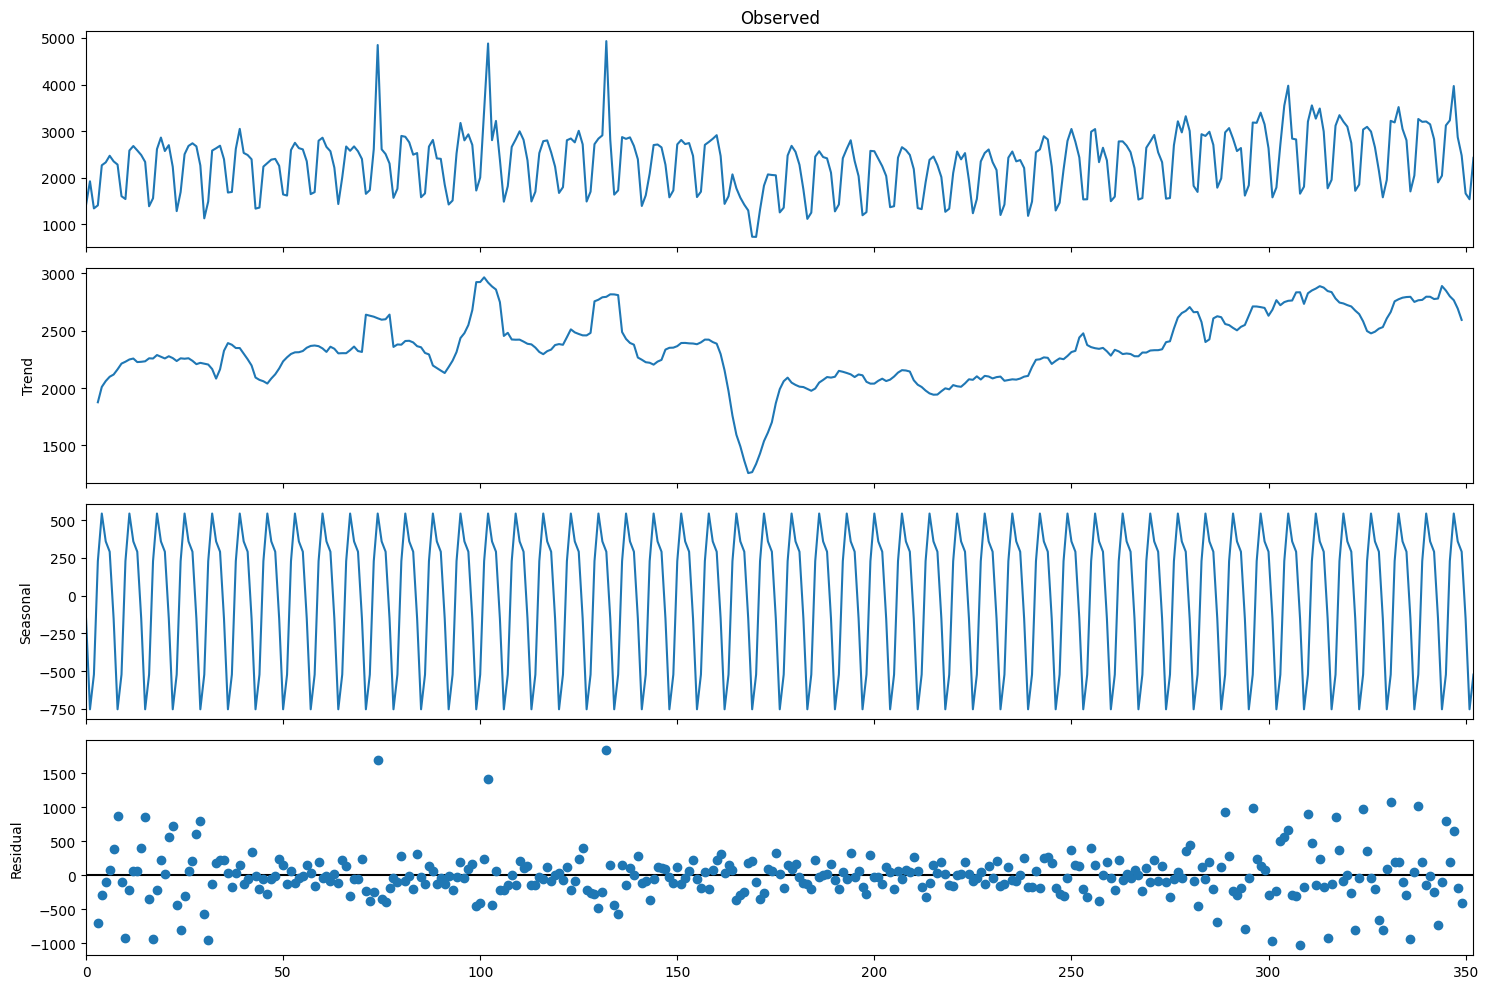

In [20]:
sm.tsa.seasonal_decompose(train_df["y"].values, period=7).plot() # differentiates trend, seasonal patterns and residuals from the given data
sm.tsa.stattools.adfuller(train_df["y"])[1]

But the seasonally differentiated series will already be stationary.

In [21]:
train_df.set_index("ds", inplace=True)

Dickey-Fuller test: p=0.000000


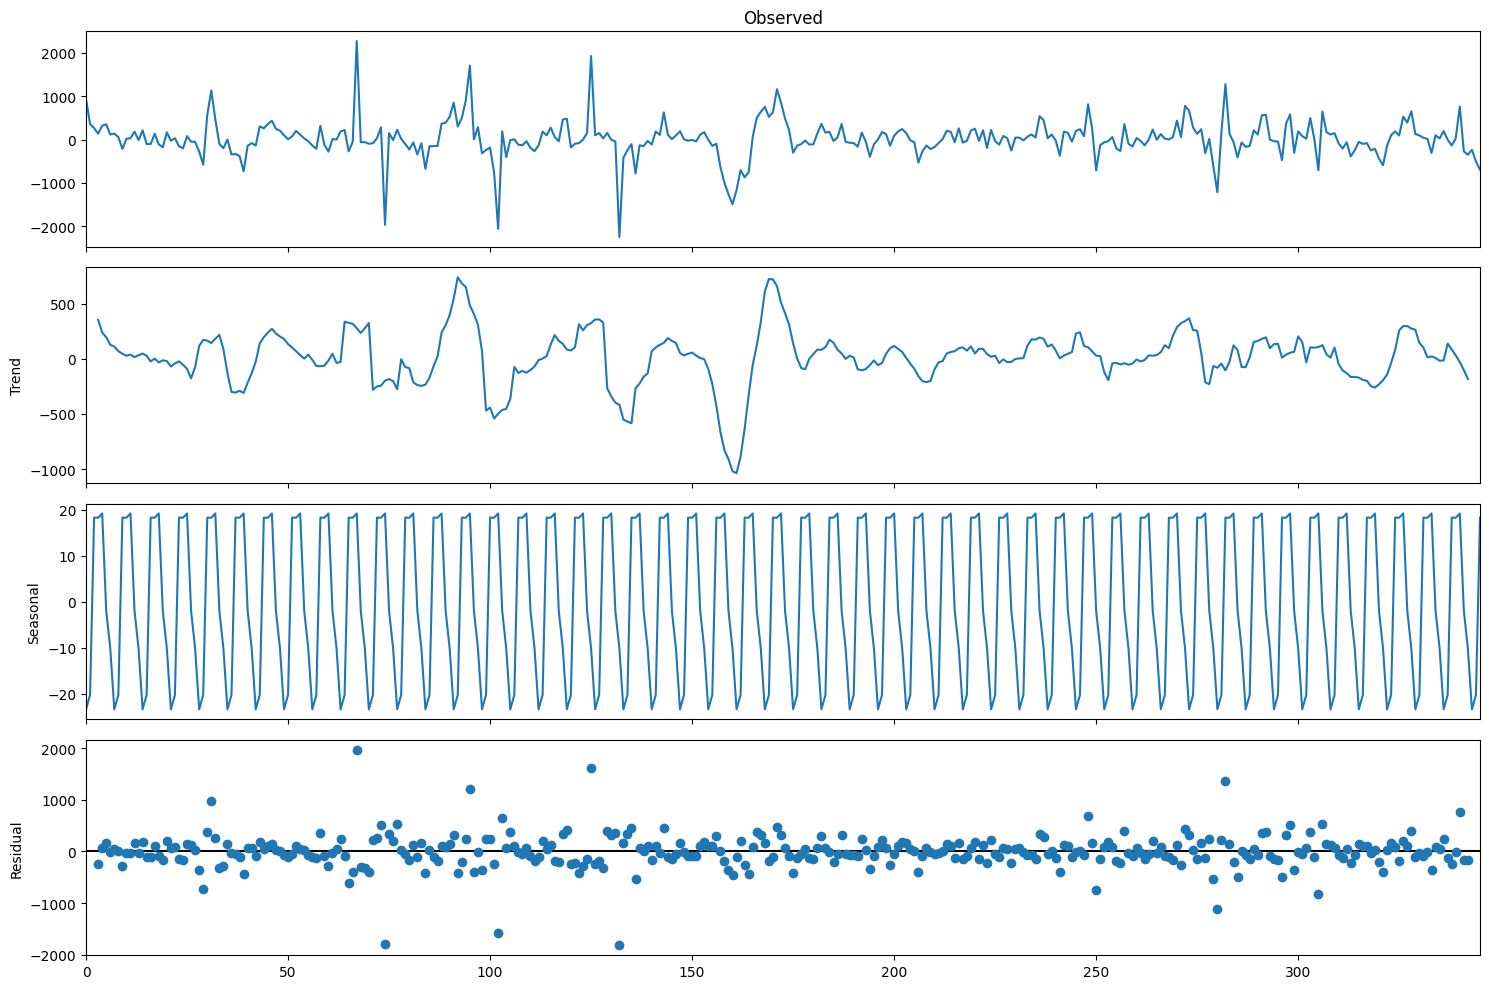

In [22]:
train_df["y_diff"] = train_df.y - train_df.y.shift(7)
sm.tsa.seasonal_decompose(train_df.y_diff[7:].values, period=7).plot()
print("Dickey-Fuller test: p=%f" % sm.tsa.stattools.adfuller(train_df.y_diff[8:])[1])

Next, we turn to the construction of the SARIMAX model (sm.tsa.statespace.SARIMAX).

Question 5: What parameters are the best for the model according to the AIC criterion?

In [23]:
train_df.head()

,y,y_diff
ds,,
2015-01-01,1414,NaN
2015-01-02,1920,NaN
2015-01-03,1338,NaN
2015-01-04,1404,NaN
2015-01-05,2264,NaN


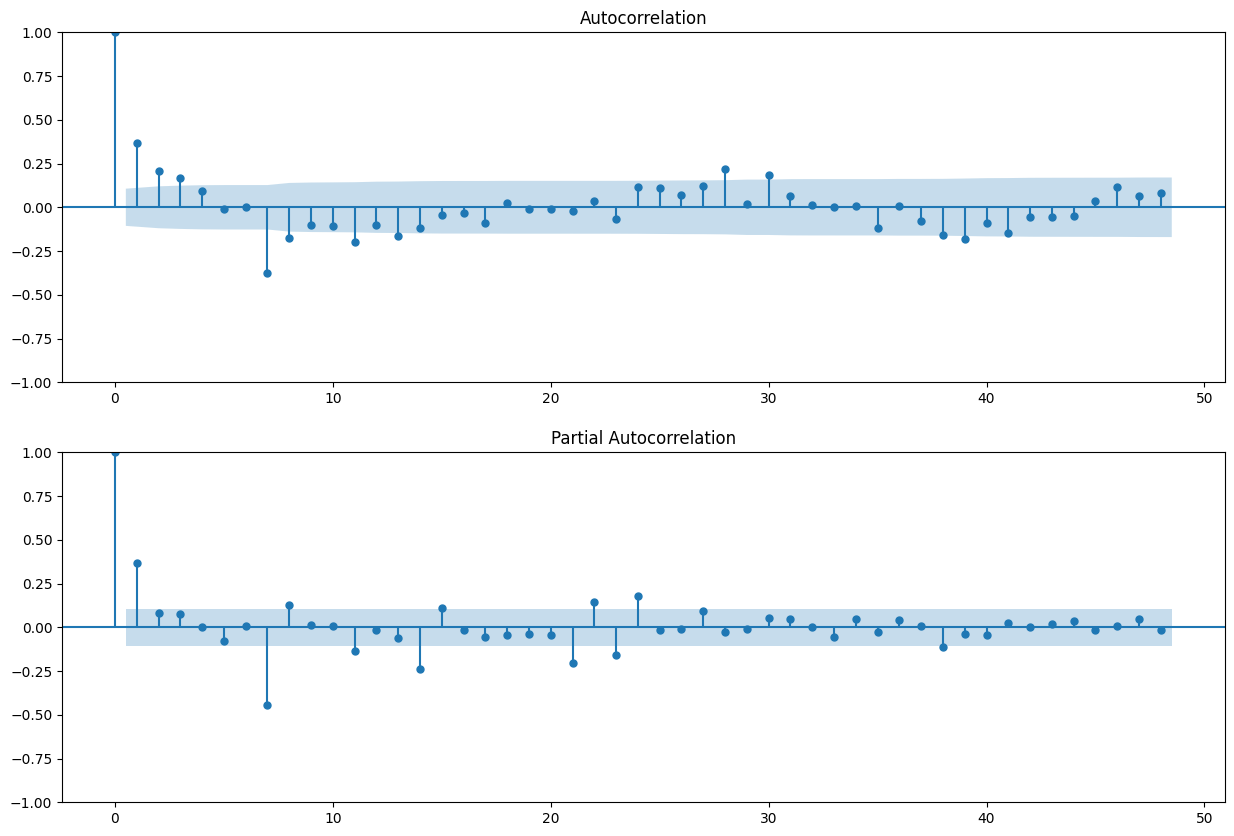

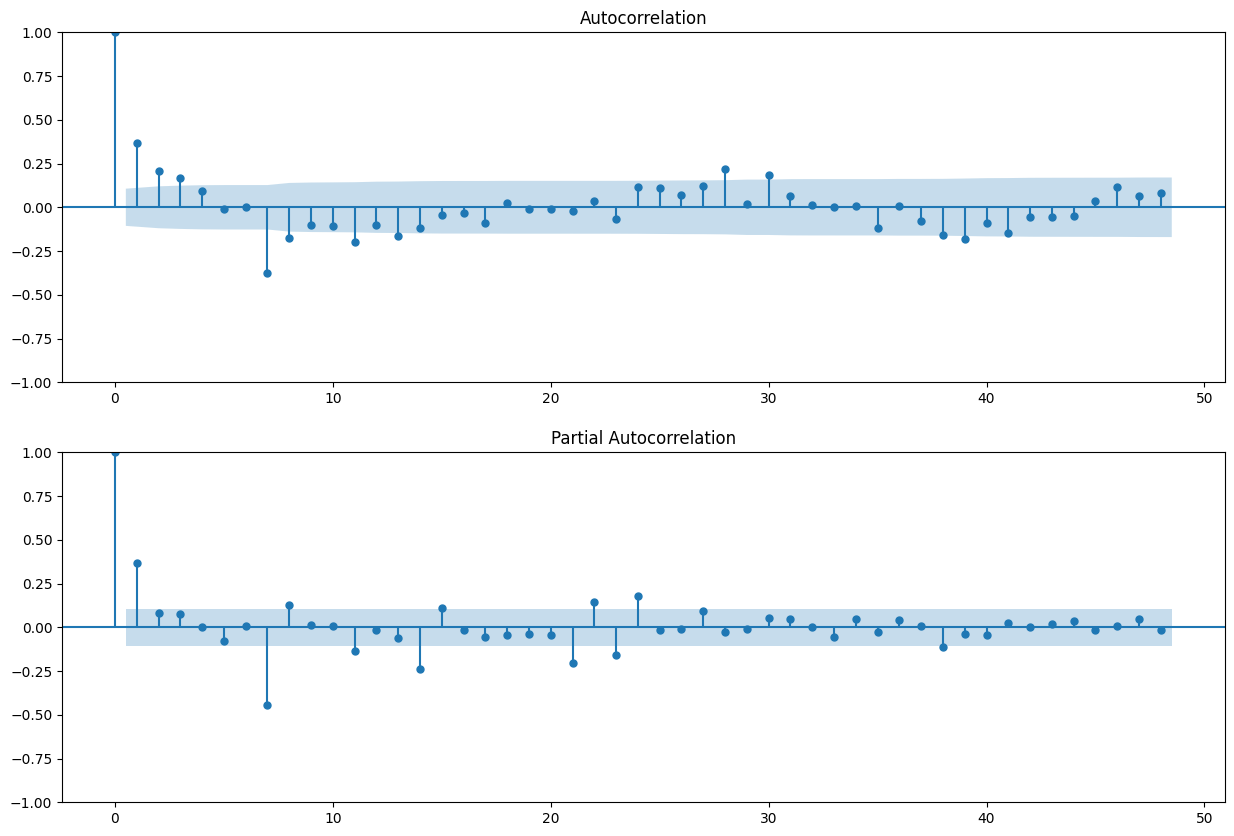

In [25]:
ax = plt.subplot(211) # Create a figure with 2 rows and 1 column, and make the first (top) subplot active. Store that subplot in ax.
sm.graphics.tsa.plot_acf(train_df.y_diff[13:].values.squeeze(), lags=48, ax=ax)

ax = plt.subplot(212)
sm.graphics.tsa.plot_pacf(train_df.y_diff[13:].values.squeeze(), lags=48, ax=ax)

In [27]:
ps = range(0, 2)
ds = range(0, 2)
qs = range(0, 4)
Ps = range(0, 4)
Ds = range(0, 3)
Qs = range(0, 2)

In [28]:
from itertools import product
parameters = product(ps, ds, qs, Ps, Ds, Qs)
parameters_list = list(parameters)
len(parameters_list)

384

In [29]:
import warnings
from tqdm.notebook import tqdm

results1 = []
best_aic = float("inf")
warnings.filterwarnings("ignore")

for param in tqdm(parameters_list):
    try:
        model = sm.tsa.statespace.SARIMAX(
            train_df["y"],
            order=(param[0], param[1], param[2]),
            seasonal_order=(param[3], param[4], param[5], 7),
        ).fit(disp=-1)
    except (ValueError, np.linalg.LinAlgError):
        continue

    aic = model.aic

    if aic < best_aic:
        best_model = model
        best_aic = aic
        best_param = param
    results1.append([param, model.aic])

  0%|          | 0/384 [00:00<?, ?it/s]

In [30]:
result_table1 = pd.DataFrame(results1)
result_table1.columns = ["parameters", "aic"]
print(result_table1.sort_values(by="aic", ascending=True).head())

             parameters          aic
66   (0, 0, 2, 3, 0, 1)    14.000000
84   (0, 0, 3, 2, 0, 1)    14.000000
42   (0, 0, 1, 3, 0, 1)  1095.866829
166  (0, 1, 2, 3, 2, 1)  4961.632628
334  (1, 1, 1, 3, 2, 1)  4962.828607


If we consider the variants proposed in the form:

In [31]:
result_table1[
    result_table1["parameters"].isin(
        [(1, 0, 2, 3, 1, 0), (1, 1, 2, 3, 2, 1), (1, 1, 2, 3, 1, 1), (1, 0, 2, 3, 0, 0)]
    )
].sort_values(by="aic")

,parameters,aic
358,"(1, 1, 2, 3, 2, 1)",4988.980251
356,"(1, 1, 2, 3, 1, 1)",5019.555903
259,"(1, 0, 2, 3, 1, 0)",5022.312525
257,"(1, 0, 2, 3, 0, 0)",5183.828883


Now do the same, but for the series with Box-Cox transformation.

In [32]:
import scipy.stats

train_df["y_box"], lambda_ = scipy.stats.boxcox(train_df["y"])
print("lambda", lambda_)

lambda 0.7328412106972967


In [33]:
results2 = []
best_aic = float("inf")

for param in tqdm(parameters_list):
    # try except is necessary, because on some sets of parameters the model can not be trained
    try:
        model = sm.tsa.statespace.SARIMAX(
            train_df["y_box"],
            order=(param[0], param[1], param[2]),
            seasonal_order=(param[3], param[4], param[5], 7),
            enforce_stationarity=False,
            enforce_invertibility=False  
        ).fit(disp=-1)

    except (ValueError, np.linalg.LinAlgError):
        continue

    aic = model.aic
    # save the best model, aic, parameters
    if aic < best_aic:
        best_model = model
        best_aic = aic
        best_param = param
    results2.append([param, model.aic])

warnings.filterwarnings("default")

  0%|          | 0/384 [00:00<?, ?it/s]

In [34]:
result_table2 = pd.DataFrame(results2)
result_table2.columns = ["parameters", "aic"]
print(result_table2.sort_values(by="aic", ascending=True).head())

             parameters          aic
263  (1, 0, 2, 3, 2, 1)  3292.640166
287  (1, 0, 3, 3, 2, 1)  3294.134383
215  (1, 0, 0, 3, 2, 1)  3294.194179
239  (1, 0, 1, 3, 2, 1)  3296.022150
383  (1, 1, 3, 3, 2, 1)  3296.540787


In [35]:
result_table2[
    result_table2["parameters"].isin(
        [(1, 0, 2, 3, 1, 0), (1, 1, 2, 3, 2, 1), (1, 1, 2, 3, 1, 1), (1, 0, 2, 3, 0, 0)]
    )
].sort_values(by="aic")

,parameters,aic
359,"(1, 1, 2, 3, 2, 1)",3326.066472
357,"(1, 1, 2, 3, 1, 1)",3335.179337
260,"(1, 0, 2, 3, 1, 0)",3335.555977
258,"(1, 0, 2, 3, 0, 0)",3509.393298


Let’s look at the forecast of the best AIC model.

Note: any AIC below 3000 is suspicious, probably caused by non-convergence with MLE optimization, we’ll pick the 3rd-best model in terms of AIC to visualize predictions.

In [36]:
best_model = sm.tsa.statespace.SARIMAX(
    train_df["y_box"],
    order=(1, 0, 2),
    seasonal_order=(3, 2, 1, 7),
    enforce_stationarity=False,  
    enforce_invertibility=False  
).fit(disp=-1)

c:\Users\rahul\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.



In [37]:
print(best_model.summary())

                                      SARIMAX Results                                      
Dep. Variable:                               y_box   No. Observations:                  353
Model:             SARIMAX(1, 0, 2)x(3, 2, [1], 7)   Log Likelihood               -1638.320
Date:                             Sun, 16 Aug 2026   AIC                           3292.640
Time:                                     23:03:21   BIC                           3322.711
Sample:                                          0   HQIC                          3304.652
                                             - 353                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8153      0.115      7.091      0.000       0.590       1.041
ma.L1         -0.3308      

Student's test: p=0.293588
Dickey-Fuller test: p=0.000000


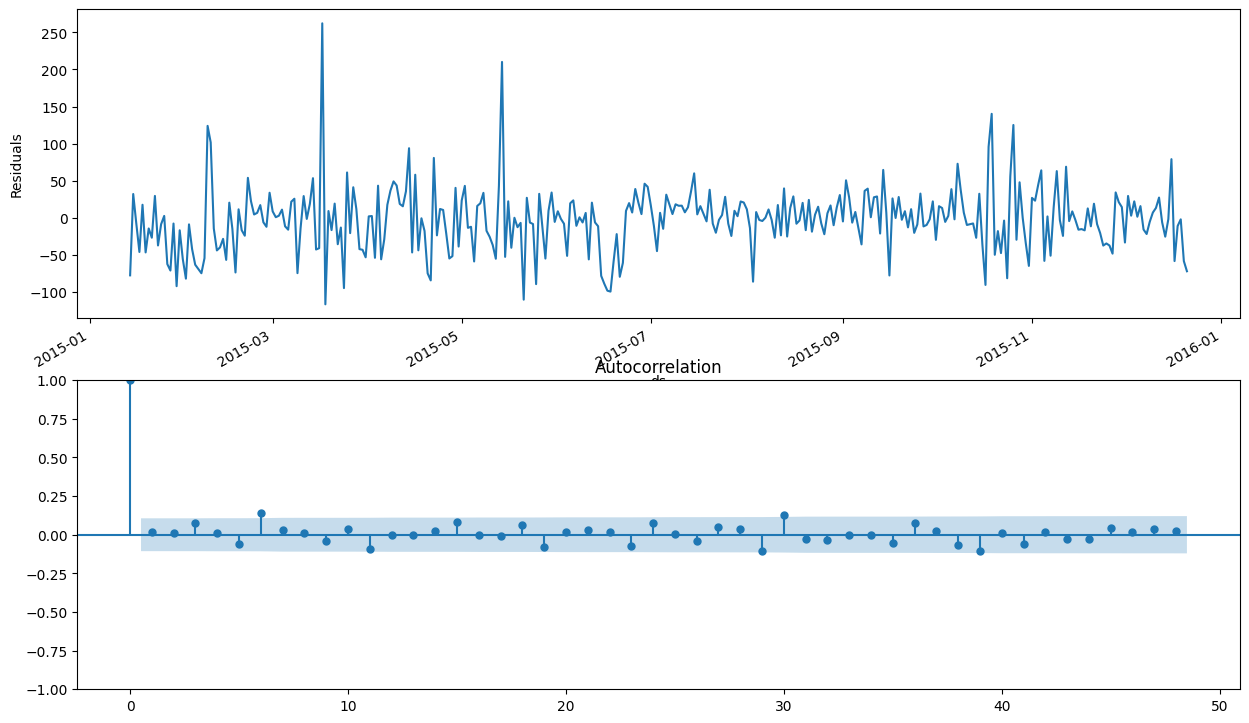

In [40]:
plt.subplot(211)
best_model.resid[13:].plot()
plt.ylabel(u"Residuals")

ax = plt.subplot(212)
# .squeeze converts to 1d array
sm.graphics.tsa.plot_acf(best_model.resid[13:].values.squeeze(), lags=48, ax=ax) 

print("Student's test: p=%f" % stats.ttest_1samp(best_model.resid[13:], 0)[1])
print("Dickey-Fuller test: p=%f" % sm.tsa.stattools.adfuller(best_model.resid[13:])[1])

In [41]:
def invboxcox(y, lambda_):
    if lambda_ == 0:
        return np.exp(y)
    else:
        return np.exp(np.log(lambda_ * y + 1) / lambda_)

C:\Users\rahul\AppData\Local\Temp\ipykernel_22468\3443010222.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Text(0, 0.5, 'wiki pageviews')

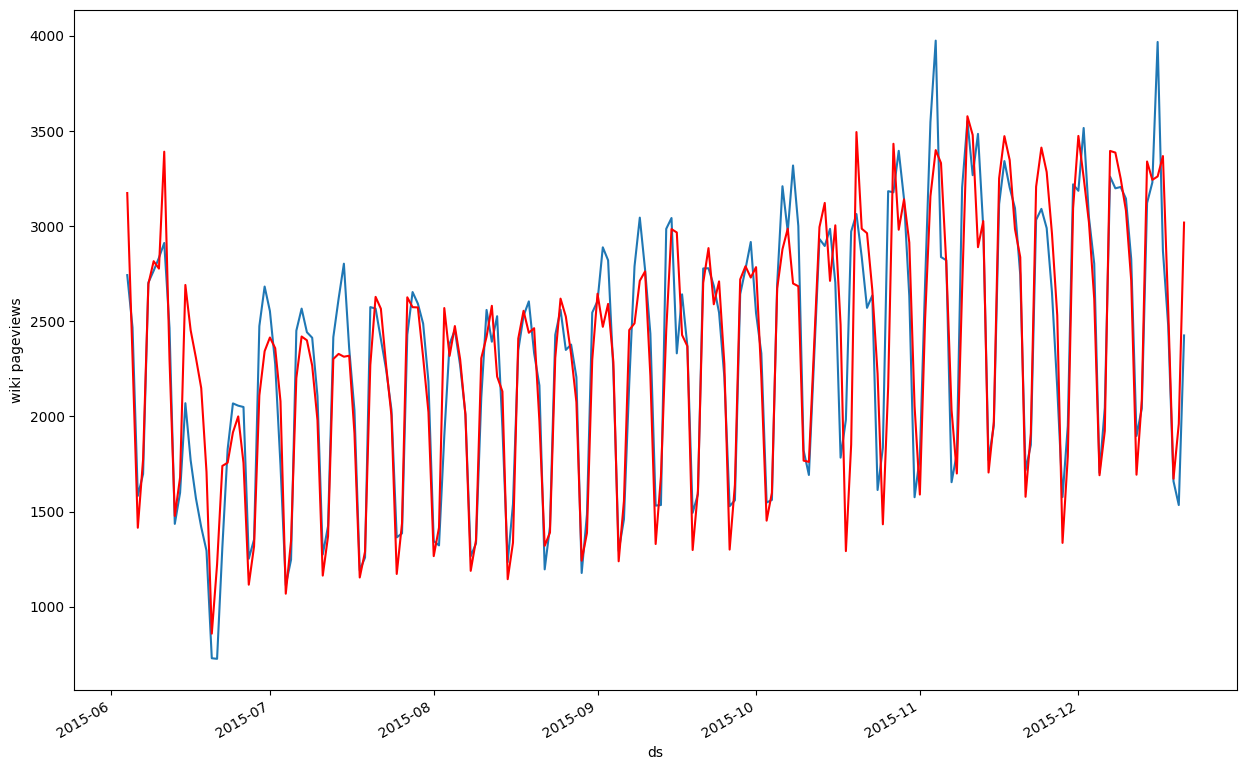

In [43]:
train_df["arima_model"] = invboxcox(best_model.fittedvalues, lambda_)

train_df.y.tail(200).plot()
train_df.arima_model[13:].tail(200).plot(color="r")
plt.ylabel("wiki pageviews")